## APPENDIX B: Reproducibility audit

This is the Reproducibility audit of the code from Cheng (2025) By doin this reproducibility audit, we can check if the code in this file is consistent per run and can be able to use this file as a foundation to build the code for my own models.

### Results: 
The outputs are almost identical to each other, with the only slight difference being the percentage of loss of the factor-based model, which is 3.10% in Cheng (2025) study and 3.19% in the audit version. Considering that Monte Carlo simulates randomly per run, this slight difference is justifiable. 

Original Github link of Cheng (2025): https://github.com/Chengyueminga/MarketRisk_VaR 
Code file Github link: https://github.com/Chengyueminga/MarketRisk_VaR/blob/main/Beta-Based%20Risk%20Factor%20VaR%20Simulation%20for%20Basel%20III%20Backtesting%20.ipynb   

Reference: Cheng, Y. (2025). Monte Carlo-based VaR estimation and backtesting under Basel III. Risks, 13(8), 146. https://www.mdpi.com/2227-9091/13/8/146 




In [1]:
import json

config = {
    "tickers": ['AAPL', 'MSFT', 'NVDA', 'GOOG', 'AMD'],
    "weights": [0.3, 0.25, 0.2, 0.15, 0.1],
    "start": "2023-01-01",
    "end": "2025-12-31",
    "train_start": "2023-01-01",
    "train_end": "2024-04-30",
    "test_start": "2024-05-01",
    "test_end": "2025-05-01",
    "confidence":0.99
}

with open("portfolio_config.json", "w") as f:
    json.dump(config, f, indent=9)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from IPython.display import Markdown
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:

def get_price_data(tickers, start_date="2020-01-01", end_date="2024-12-31"):
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust = True, progress=False)['Close']
    return data

In [4]:
with open("portfolio_config.json", "r") as f:
    config = json.load(f)

tickers = config["tickers"]
weights = config["weights"]
start = config["start"]
end = config["end"]
train_start = config["train_start"]
train_end = config["train_end"]
test_start = config["test_start"]
test_end = config["test_end"]
confidence = config["confidence"]

Port1_Ticker_P = get_price_data(tickers, train_start, train_end)
Port1_Ticker_P.head()

Ticker,AAPL,AMD,GOOG,MSFT,NVDA
Date,,,,,
2023-01-03,123.096031,64.019997,88.969551,233.452820,14.299909
2023-01-04,124.365669,64.660004,87.987633,223.240829,14.733453
2023-01-05,123.046822,62.330002,86.063438,216.624481,14.249964
2023-01-06,127.574196,63.959999,87.442108,219.177460,14.843336
2023-01-09,128.095856,67.239998,88.076889,221.311462,15.611525


In [5]:
risk_factor_proxies = {
    'Market': 'SPY',     # SP500
    'Tech': 'XLK',       # Tech sector risk
    'IR': 'TLT',         # Interest rate sensitivity
    'Mtum': 'MTUM',      # Momentum factor
    'Vol': '^VIX',       # Volatility (non-tradable index)
    'Value': 'VLUE',     # Value-style equities
    'Growth': 'IWF'      # Growth-style equities
}

In [6]:
Factor_Tickers = list(risk_factor_proxies.values())
##tickers is the portfolio tickers, which is defined from the config and used for part 1 (portfolio1)
All_Tickers = tickers +Factor_Tickers

In [7]:
def compute_log_returns(price_df):
    log_returns = np.log(price_df / price_df.shift(1))
    return log_returns.dropna()

In [8]:
Price_All = get_price_data(All_Tickers, train_start, train_end)

Price_All = get_price_data(All_Tickers, train_start, train_end)
Log_All_R = compute_log_returns(Price_All)

In [9]:
##Linear Regression
Portfolio_R = Log_All_R[tickers]  
PortfolioReturn = Portfolio_R @ weights #y

Factor_R = Log_All_R[Factor_Tickers]  #x 

In [10]:
def RunOLSRegression(PortfolioReturn: pd.Series,
                     FactorReturns: pd.DataFrame) -> pd.DataFrame:

    X = sm.add_constant(FactorReturns)
    y = PortfolioReturn

    model = sm.OLS(y, X).fit()

    result_df = pd.DataFrame({
        'Factor': model.params.index,
        'Beta': model.params.values,
        'T-Stat': model.tvalues.values,
        'P-Value': model.pvalues.values
    })

    result_df = result_df[result_df['Factor'] != 'const']
    result_df['P-Value'] = result_df['P-Value'].round(4)
    result_df = result_df[['Factor', 'Beta', 'T-Stat', 'P-Value']]

    return result_df

In [11]:
def GetPortR_Square(PortfolioReturn: pd.DataFrame,
                    FactorReturns: pd.DataFrame) -> tuple[float, float]:

    X = sm.add_constant(FactorReturns)
    y = PortfolioReturn
    Model = sm.OLS(y, X).fit()
    return Model.rsquared.round(2), Model.rsquared_adj.round(2)

In [12]:
GetPortR_Square(PortfolioReturn, Factor_R)

(np.float64(0.92), np.float64(0.91))

In [13]:
regression_result = RunOLSRegression(PortfolioReturn, Factor_R)

In [14]:
regression_result 

,Factor,Beta,T-Stat,P-Value
1,SPY,-0.503091,-2.258196,0.0246
2,XLK,0.808599,11.249051,0.0000
3,TLT,-0.020340,-0.895366,0.3713
4,MTUM,-0.198959,-4.705938,0.0000
5,^VIX,-0.007696,-1.141462,0.2545
6,VLUE,-0.231647,-2.960728,0.0033
7,IWF,1.105298,6.485139,0.0000


In [15]:
def CalculateVIF(FactorReturns: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate Variance Inflation Factor (VIF) for each factor.
    """
    vif_data = pd.DataFrame()
    vif_data["Factor"] = FactorReturns.columns
    vif_data["VIF"] = [variance_inflation_factor(FactorReturns.values, i)
                       for i in range(FactorReturns.shape[1])]
    return vif_data

In [16]:
VIF_result = CalculateVIF(Factor_R)

In [17]:
VIF_result

,Factor,VIF
0,SPY,54.164697
1,XLK,12.143135
2,TLT,1.046674
3,MTUM,2.783502
4,^VIX,2.200313
5,VLUE,8.193151
6,IWF,49.712068


In [18]:
FactorR = Factor_R.drop(columns=["TLT","IWF","^VIX","SPY"]) 


In [19]:
GetPortR_Square(PortfolioReturn, FactorR)

(np.float64(0.89), np.float64(0.89))

In [20]:
regression_result = RunOLSRegression(PortfolioReturn, FactorR)

In [21]:
regression_result 

,Factor,Beta,T-Stat,P-Value
1,XLK,1.390296,40.554605,0.0000
2,MTUM,-0.083366,-1.987666,0.0477
3,VLUE,-0.305529,-7.512166,0.0000


In [22]:
FactorR.corr()

Ticker,XLK,MTUM,VLUE
Ticker,,,
XLK,1.000000,0.699360,0.608388
MTUM,0.699360,1.000000,0.610274
VLUE,0.608388,0.610274,1.000000


In [23]:
VIF_result = CalculateVIF(FactorR)
VIF_result 

,Factor,VIF
0,XLK,2.192066
1,MTUM,2.202143
2,VLUE,1.779850


In [24]:
regression_result = RunOLSRegression(PortfolioReturn, FactorR)
regression_result

,Factor,Beta,T-Stat,P-Value
1,XLK,1.390296,40.554605,0.0000
2,MTUM,-0.083366,-1.987666,0.0477
3,VLUE,-0.305529,-7.512166,0.0000


In [25]:
def SimulateFactors(FactorReturns: pd.DataFrame, NSim: int = 10000):
    """
    Simulate multivariate normal factor returns based on historical covariance and mean.
    """
    assert isinstance(NSim, int), "NSim must be an integer"

    FactorCov = FactorReturns.cov().values
    FactorMean = FactorReturns.mean().values
    Simulated = np.random.multivariate_normal(mean=FactorMean, cov=FactorCov, size=NSim)

    return pd.DataFrame(Simulated, columns=FactorReturns.columns)

In [26]:
model = sm.OLS(PortfolioReturn, sm.add_constant(FactorR)).fit()
PortfolioBeta = model.params.drop("const")

Simulated_Factor_DF = SimulateFactors(FactorR, 1000)[PortfolioBeta.index]
SimulatedPortfolioReturn = Simulated_Factor_DF @ PortfolioBeta.values

In [27]:
PortfolioBeta.index

Index(['XLK', 'MTUM', 'VLUE'], dtype='object')

In [28]:
Simulated_Factor_DF

Ticker,XLK,MTUM,VLUE
0,0.011708,0.008542,0.011743
1,0.026223,0.024677,0.020873
2,-0.007279,-0.001782,-0.009233
3,0.017218,0.011575,0.003920
4,0.011116,0.008620,0.004496
...,...,...,...
995,-0.009474,0.003464,-0.000259
996,0.021079,0.011195,0.014249
997,-0.008491,0.004674,0.009688
998,-0.014397,-0.008091,-0.016361


In [29]:
SimulatedPortfolioReturn

0      0.011977
1      0.028023
2     -0.007150
3      0.021776
4      0.013363
         ...   
995   -0.013381
996    0.024020
997   -0.015154
998   -0.014342
999   -0.018853
Length: 1000, dtype: float64

In [30]:
SimulatedPortfolioVaR = np.percentile(SimulatedPortfolioReturn, (1-confidence)*100)
print(f"{int(confidence*100)}% VaR: {SimulatedPortfolioVaR:.2%}")

99% VaR: -3.19%


In [31]:
SimulatedPortfolioReturn

0      0.011977
1      0.028023
2     -0.007150
3      0.021776
4      0.013363
         ...   
995   -0.013381
996    0.024020
997   -0.015154
998   -0.014342
999   -0.018853
Length: 1000, dtype: float64

In [32]:
Log_All_R

Ticker,AAPL,AMD,GOOG,IWF,MSFT,MTUM,NVDA,SPY,TLT,VLUE,XLK,^VIX
Date,,,,,,,,,,,,
2023-01-04,0.010261,0.009947,-0.011098,0.003521,-0.044729,-0.000906,0.029867,0.007691,0.013607,0.015567,0.002593,-0.039640
2023-01-05,-0.010661,-0.036700,-0.022112,-0.016301,-0.030086,-0.000697,-0.033366,-0.011479,0.004172,-0.005090,-0.019612,0.020239
2023-01-06,0.036133,0.025815,0.015892,0.023446,0.011716,0.016601,0.040797,0.022673,0.018229,0.025087,0.028874,-0.061042
2023-01-09,0.004081,0.050010,0.007233,0.005198,0.009689,-0.013467,0.050458,-0.000567,0.005310,-0.002544,0.011558,0.038984
2023-01-10,0.004447,0.011974,0.004943,0.007379,0.007588,0.005132,0.017821,0.006988,-0.016689,0.007087,0.006163,-0.065358
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-23,0.006372,0.024128,0.012395,0.014705,0.016351,0.021221,0.035881,0.011797,0.000337,0.007911,0.014717,-0.076654
2024-04-24,0.012622,-0.003487,0.007352,0.000185,0.003649,-0.004590,-0.033883,-0.000475,-0.007102,0.003108,0.004555,0.017688
2024-04-25,0.005134,0.013224,-0.019747,-0.006315,-0.024800,-0.004611,0.036416,-0.003806,-0.007038,-0.006031,-0.002174,-0.038294


In [33]:
test_start = config["test_start"]
test_end = config["test_end"]

test_prices = get_price_data(tickers, test_start, test_end)
test_returns = compute_log_returns(test_prices)
test_P_returns = test_returns[tickers]  
test_P_return = test_P_returns @ weights

In [34]:
test_P_return 

Date
2024-05-02    0.018841
2024-05-03    0.033183
2024-05-06    0.012984
2024-05-07   -0.003001
2024-05-08   -0.001136
                ...   
2025-04-24    0.029008
2025-04-25    0.017130
2025-04-28   -0.004945
2025-04-29    0.003215
2025-04-30    0.002663
Length: 249, dtype: float64

In [35]:
def backtest_VaR(real_returns, VaR):
    """
    Backtest VaR: support both static (single value) and rolling (Series) VaR.

    Parameters:
        real_returns (pd.Series): Actual portfolio returns.
        VaR (float or pd.Series): Either a single VaR value or a rolling VaR series.

    Returns:
        dict: violations, total, rate, zone
    """
    if not isinstance(real_returns, pd.Series):
        real_returns = pd.Series(real_returns)

    # Case 1: Rolling VaR (Series)
    if isinstance(VaR, pd.Series):
        VaR = VaR.loc[real_returns.index]  # ensure alignment
        violations = real_returns < VaR
    else:
        # Case 2: Static VaR (float)
        violations = real_returns < VaR

    num_violations = violations.sum()
    total_days = len(real_returns)
    violation_rate = num_violations / total_days

    # Basel traffic light zones
    if num_violations <= 4:
        zone = "Green"
    elif num_violations <= 9:
        zone = "Yellow"
    else:
        zone = "Red"

    return {
        "violations": int(num_violations),
        "total": total_days,
        "rate": violation_rate,
        "zone": zone
    }

In [36]:
backtest_VaR(test_P_return , SimulatedPortfolioVaR)

{'violations': 13,
 'total': 249,
 'rate': np.float64(0.05220883534136546),
 'zone': 'Red'}

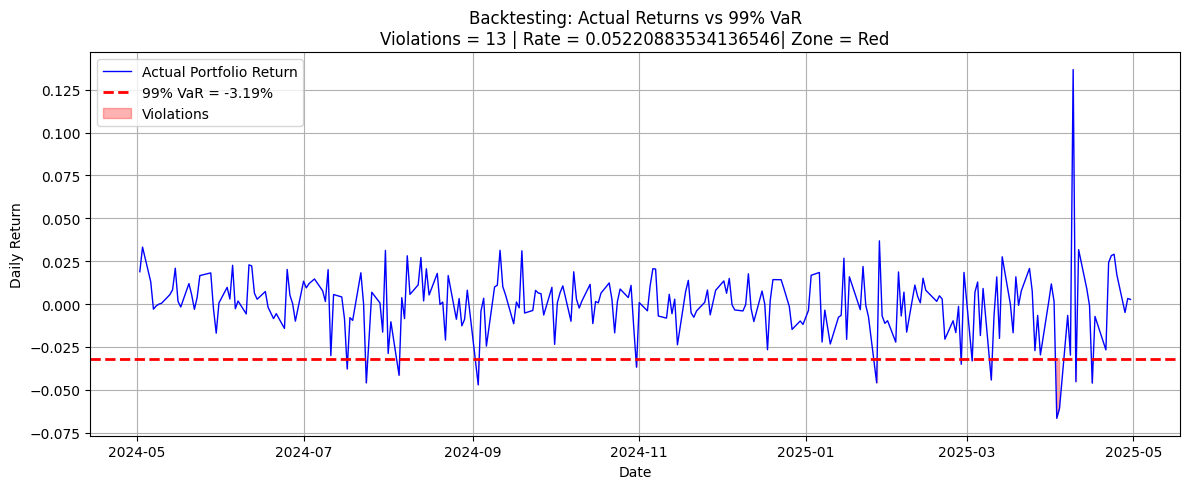

In [37]:
x = test_P_return.index
y = test_P_return.values.astype("float64")
VaR_line = SimulatedPortfolioVaR
y2 = np.full_like(y, VaR_line)
mask = y < VaR_line


result = backtest_VaR(test_P_return, SimulatedPortfolioVaR)


plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Actual Portfolio Return", color="blue", linewidth=1)
plt.axhline(y=VaR_line, color="red", linestyle="--", linewidth=2,
            label=f"99% VaR = {VaR_line:.2%}")
plt.fill_between(x, y, y2, where=mask, color='red', alpha=0.3, label="Violations")

plt.title(f"Backtesting: Actual Returns vs 99% VaR\n"
          f"Violations = {result['violations']} | "
          f"Rate = {result['rate']}| Zone = {result['zone']}")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
Markdown(f"""
### Output: Backtest Result Summary

- Total backtesting days: **{result['total']}**
- VaR threshold (99%): **{SimulatedPortfolioVaR:.2%}**
- Violations: **{result['violations']}**  
- Violation rate: **{result['rate']}**

**Basel zone**: `{result['zone']}`  
→ Based on the number of violations, this model falls in the **{result['zone']} zone** under the Basel backtesting framework.
""")


### Output: Backtest Result Summary

- Total backtesting days: **249**
- VaR threshold (99%): **-3.19%**
- Violations: **13**  
- Violation rate: **0.05220883534136546**

**Basel zone**: `Red`  
→ Based on the number of violations, this model falls in the **Red zone** under the Basel backtesting framework.


### Supplementary Section: Rolling Backtest

This section extends the baseline VaR backtest by incorporating a rolling evaluation over a 250-day estimation window. The simulation is updated daily, and violations are tracked dynamically to reflect changing market conditions.

In [39]:
## Pls note: beta parameter need to include both beta and the tickers
def generate_rolling_VaR_series(
    factor_returns,
    beta,
    start_date=None,
    end_date=None,
    window=250,
    simulations=10000,
    confidence=0.99

):
    # Step 0: Preprocess
    factor_returns = factor_returns.copy()
    factor_returns.index = pd.to_datetime(factor_returns.index)
    all_dates = factor_returns.index

    # Step 1: Validate beta
    if not isinstance(beta, pd.Series):
        raise ValueError("beta must be a pandas Series with index = factor tickers.")

    factor_names = list(beta.index)

    # Step 2: Check all beta factors exist in factor_returns
    missing_factors = [f for f in factor_names if f not in factor_returns.columns]
    if missing_factors:
        raise ValueError(f"Missing factors in factor_returns: {missing_factors}")

    # Step 3: Subset and reorder factor_returns
    factor_returns = factor_returns[factor_names]
    beta_vector = beta.values.reshape(1, -1)  # shape: (1, F)

    # Step 4: Date handling
    if len(factor_returns) <= window:
        raise ValueError(f"Factor returns too short: need at least {window + 1} rows.")

    if start_date is None:
        start_loc = window
        start_date = all_dates[start_loc]
    else:
        start_date = pd.to_datetime(start_date)
        if start_date not in all_dates:
            raise ValueError(f"start_date {start_date.date()} not in factor_returns.")
        start_loc = all_dates.get_loc(start_date)
        if start_loc < window:
            raise ValueError(f"start_date too early — need {window} days of history.")

    if end_date is None:
        end_date = all_dates[-1]
    else:
        end_date = pd.to_datetime(end_date)
        if end_date not in all_dates:
            raise ValueError(f"end_date {end_date.date()} not in factor_returns.")
    end_loc = all_dates.get_loc(end_date)

    # Step 5: Rolling simulation
    rolling_VaR = []

    for i in range(start_loc, end_loc + 1):
        window_factors = factor_returns.iloc[i - window:i]
        cov_matrix = np.cov(window_factors.T)

        sim_factors = np.random.multivariate_normal(
            mean=np.zeros(len(beta)),
            cov=cov_matrix,
            size=simulations
        )  # shape: (simulations x F)

        sim_portfolio = sim_factors @ beta_vector.T  # shape: (simulations x 1)
        var_i = np.percentile(sim_portfolio, (1 - confidence) * 100)

        rolling_VaR.append((all_dates[i], var_i))

    return pd.Series([v[1] for v in rolling_VaR], index=[v[0] for v in rolling_VaR])

In [40]:
##Total means to add all the data from start to end, for rolling backest
##All means to add all the tickers in risk factor simulation

Price_Total_All = get_price_data(All_Tickers, start, end)
Price_Total_All = get_price_data(All_Tickers, start, end)
Log_Total_R = compute_log_returns(Price_Total_All)

In [41]:
rolling_var = generate_rolling_VaR_series(Log_Total_R, PortfolioBeta,test_start, test_end)

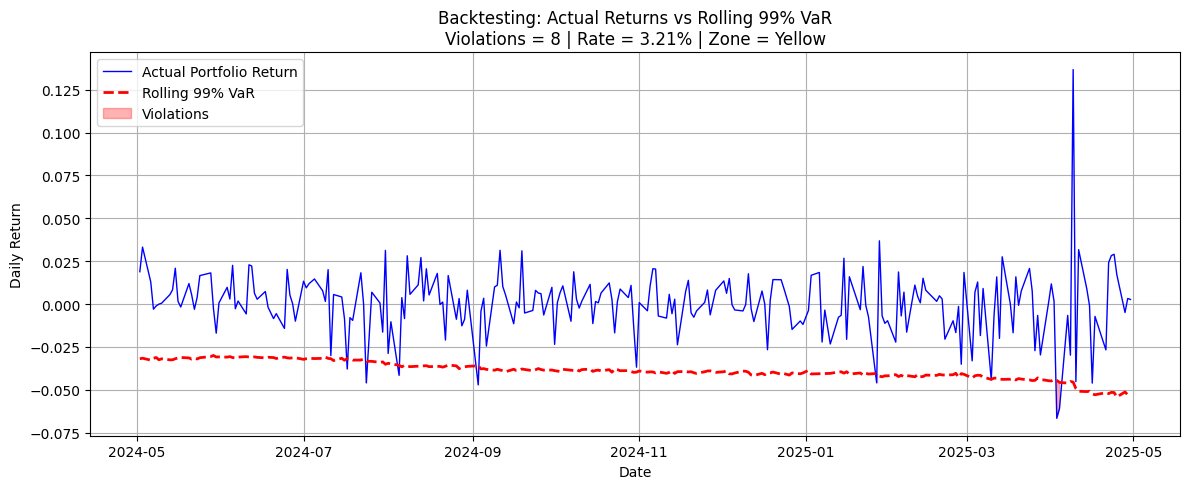

In [42]:
# Ensure rolling VaR and portfolio return are aligned on dates
aligned_index = rolling_var.index.intersection(test_P_return.index)

rolling_var = rolling_var.loc[aligned_index]
test_P_return_aligned = test_P_return.loc[aligned_index]

x = test_P_return.loc[rolling_var.index].index
y = test_P_return.loc[rolling_var.index].values.astype("float64")
y2 = rolling_var.values
mask = y < y2


result = backtest_VaR(test_P_return.loc[rolling_var.index], rolling_var)


plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Actual Portfolio Return", color="blue", linewidth=1)
plt.plot(x, y2, color="red", linestyle="--", linewidth=2, label="Rolling 99% VaR")
plt.fill_between(x, y, y2, where=mask, color='red', alpha=0.3, label="Violations")

plt.title(f"Backtesting: Actual Returns vs Rolling 99% VaR\n"
          f"Violations = {result['violations']} | "
          f"Rate = {result['rate']:.2%} | Zone = {result['zone']}")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
Markdown(f"""
### Output: Rolling VaR Backtest Result Summary

- Total backtesting days: **{result['total']}**
- VaR type: **Rolling 99% Monte Carlo VaR**
- Violations: **{result['violations']}**  
- Violation rate: **{result['rate']:.2%}**

**Basel zone**: `{result['zone']}`  
→ Based on the number of violations over the test period, this portfolio's risk model falls in the **{result['zone']} zone** under the Basel traffic light framework.

The rolling VaR approach dynamically reflects changing market conditions, and this backtest provides a regulatory-style validation of its performance using historical return alignment. The violation rate is evaluated against Basel III thresholds:
- **Green** (≤4 violations): model accepted
- **Yellow** (5–9): model requires closer monitoring
- **Red** (≥10): model may be underestimating risk
""")


### Output: Rolling VaR Backtest Result Summary

- Total backtesting days: **249**
- VaR type: **Rolling 99% Monte Carlo VaR**
- Violations: **8**  
- Violation rate: **3.21%**

**Basel zone**: `Yellow`  
→ Based on the number of violations over the test period, this portfolio's risk model falls in the **Yellow zone** under the Basel traffic light framework.

The rolling VaR approach dynamically reflects changing market conditions, and this backtest provides a regulatory-style validation of its performance using historical return alignment. The violation rate is evaluated against Basel III thresholds:
- **Green** (≤4 violations): model accepted
- **Yellow** (5–9): model requires closer monitoring
- **Red** (≥10): model may be underestimating risk
